In [ ]:
Sys.time()

In [ ]:
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(data.table))
suppressPackageStartupMessages(library(repr))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(tidyr))
suppressPackageStartupMessages(library(stringr))
suppressPackageStartupMessages(library(cowplot))
suppressPackageStartupMessages(library(colorspace))
suppressPackageStartupMessages(library(ComplexHeatmap))
suppressPackageStartupMessages(library(circlize))
suppressPackageStartupMessages(library(RColorBrewer))
suppressPackageStartupMessages(library(ggplotify))

In [ ]:
projdir <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures'

donors <- c('C29', 'C37', 'C38', 'C39')
donor_order <- donors
donor_hexes <- c('#2851B0', '#C445B8', '#70373D', '#CFCF42')

tmp_order <- c('Start', 'Sendai', 'Skin', 'Inflamed', 'Delayed',
               'Fail1', 'Inter1', 'Inter2', 'Fail2', 'IPS')
clust_hexes <- c('#C4B921', '#707332', '#3CADBA', '#83E880', '#9C4F43',
                 '#4F7EB8', '#B07620', '#D698D0', '#0F2061', '#7F5194')
names(clust_hexes) <- tmp_order

ips_dict <- c('IPS_main' = 'IPS_1', 'IPS_alt' = 'IPS_2')
cc_hexes <- c('#E69F00', '#0072B2')

c29_order <- c('Early_1', 'Early_2', 'Early_3', 'Early_4', 'Early_5',
               'Early_6', 'Early_7', 'Early_8', 'Transitional_1', 'Late_1', 'Late_2')
c37_order <- c('Early_1', 'Early_2', 'Early_3', 'Early_4', 'Early_5',
               'Early_6', 'Early_7', 'Transitional_1', 'Late_1')
c38_order <- c('Early_1', 'Early_2', 'Early_3', 'Early_4', 'Early_5',
               'Early_6', 'Early_7', 'Early_8', 'Early_9', 'Transitional_1', 'Late_1')
c39_order <- c('Early_1', 'Early_2', 'Early_3', 'Early_4', 'Early_5',
               'Early_6', 'Early_7', 'Early_8', 'Early_9', 'Early_10', 'Early_11',
               'Early_12', 'Early_13', 'Early_14', 'Early_15',
               'Transitional_1', 'Late_1', 'Late_2')
clust_list <- list(c29_order, c37_order, c38_order, c39_order)

c29_palette <- c('#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
                 '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#aec7e8')
c37_palette <- c('#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00',
                 '#ffff33', '#a65628', '#f781bf', '#999999')
c38_palette <- darken(c('#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854',
                        '#ffd92f', '#e5c494', '#b3b3b3', '#1b9e77', '#d95f02', '#7570b3'), amount = 0.3)
c39_palette <- darken(c('#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#66a61e', '#e6ab02',
                        '#a6761d', '#666666', '#a6cee3', '#1f78b4', '#b2df8a', '#33a02c',
                        '#fb9a99', '#e31a1c', '#fdbf6f', '#ff7f00', '#cab2d6', '#6a3d9a'), amount = 0.3)
names(c29_palette) <- c29_order
names(c37_palette) <- c37_order
names(c38_palette) <- c38_order
names(c39_palette) <- c39_order
all_palettes <- list(c29_palette, c37_palette, c38_palette, c39_palette)

base_theme <- theme(
    axis.line = element_blank(),
    panel.border = element_blank(),
    panel.grid = element_blank(),
    panel.background = element_blank(),
    plot.background = element_blank(),
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    legend.position = 'none')

clone_theme <- theme(
    plot.title = element_text(size = 24, hjust = 0.5),
    axis.text.x = element_blank(),
    axis.text.y = element_blank(),
    axis.title.x = element_text(size = 14),
    axis.title.y = element_text(size = 14),
    axis.line = element_blank(),
    panel.border = element_blank(),
    panel.grid = element_blank(),
    panel.background = element_blank(),
    plot.background = element_blank(),
    axis.ticks = element_blank(),
    legend.position = 'none')

### A: day composition of mC clusters

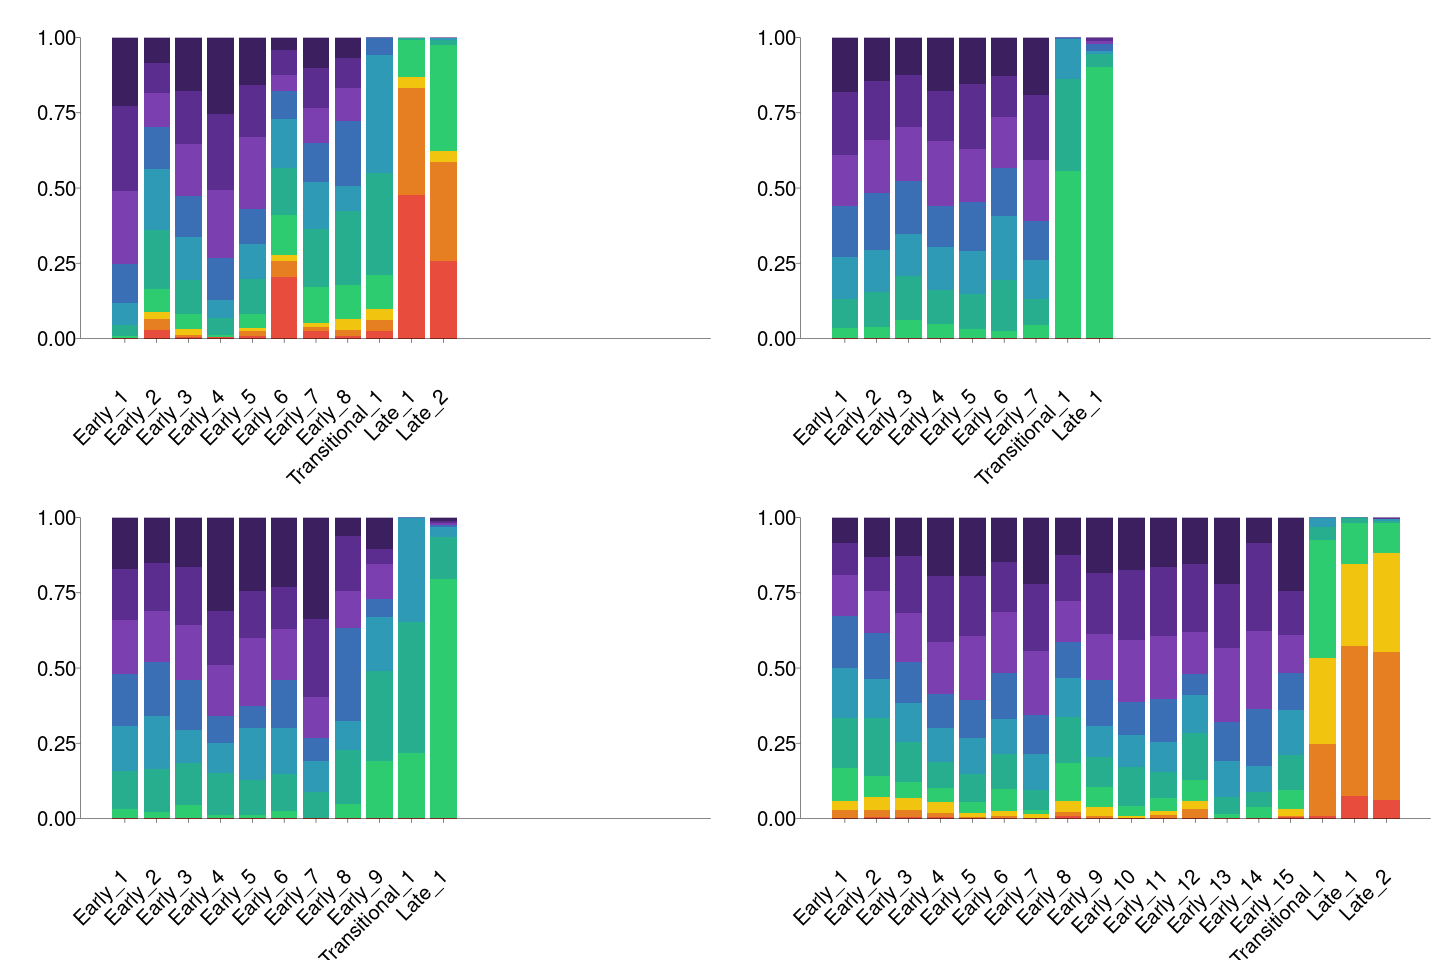

In [ ]:
tmp_times <- c('0', '1', '3', '5', '7', '9', '12', '14', '16', '18')
time_hexes <- c('#3B1F5E', '#5B2D8E', '#7B3FB0', '#3A6FB5', '#2E9AB5',
                '#27AE8F', '#2ECC71', '#F1C40F', '#E67E22', '#E84C3C')
names(time_hexes) <- tmp_times

mc_time_dist <- as.data.frame(fread(paste0(projdir, '/csv/figure2/snmct_mc_cluster_time_props.csv')))
colnames(mc_time_dist) <- mc_time_dist[1,]
mc_time_dist <- mc_time_dist[-1,]
mc_time_dist$cluster <- gsub('Fibro', 'Early', mc_time_dist$cluster)
mc_time_dist$cluster <- gsub('Inter', 'Transitional', mc_time_dist$cluster)
mc_time_dist$cluster <- gsub('IPS', 'Late', mc_time_dist$cluster)

make_plot <- function(tmp_df, max_clusters) {

    tmp_df$x <- as.numeric(tmp_df$cluster)
    n_clusters <- nlevels(tmp_df$cluster)

    ggplot(tmp_df, aes(x = x, y = prop, fill = state)) +
      geom_col(width = 0.8) +
      scale_x_continuous(
        breaks = seq_len(n_clusters),
        labels = levels(tmp_df$cluster),
        limits = c(0.5, max_clusters + 0.5)
      ) +
      labs(x = "", y = "", title = '', fill = "Time") +
      scale_y_continuous(limits = c(0, 1), expand = c(0, 0)) +
      theme_bw() +
      clone_theme +
      theme(
        axis.text.x = element_text(
          size = 12, angle = 45, hjust = 1, color = 'black'
        ),
        axis.text.y = element_text(size = 12, color = 'black'),
        plot.title = element_text(size = 12, hjust = 0.5, color = 'black'),
        axis.title = element_text(size = 18),
        axis.ticks.x = element_line(linewidth = 0.1),
        axis.ticks.y = element_line(linewidth = 0.1),
        axis.line.x = element_line(linewidth = 0.1),
        axis.line.y = element_line(linewidth = 0.1),
        legend.position = "none"
      ) +
      scale_fill_manual(values = time_hexes)
}

max_clusters <- max(sapply(clust_list, length))
plots <- list()

for (i in seq_along(donors)) {
    d <- donors[i]
    mask <- mc_time_dist$donor == d
    tmp_dist <- mc_time_dist[mask,]
    tmp_dist <- tmp_dist[,-ncol(tmp_dist)]
    rownames(tmp_dist) <- tmp_dist$cluster
    tmp_dist <- tmp_dist[,-1]
    tmp_dist$cluster <- rownames(tmp_dist)
    df_long <- tmp_dist %>% pivot_longer(-cluster, names_to = "state", values_to = "prop")
    df_long$state <- factor(df_long$state, levels=tmp_times)
    df_long <- df_long %>% mutate(cluster = recode(cluster, !!!ips_dict))
    df_long$cluster <- gsub('Fibro', 'Early', df_long$cluster)
    df_long$cluster <- gsub('Inter', 'Transitional', df_long$cluster)
    df_long$cluster <- gsub('IPS', 'Late', df_long$cluster)

    mc_order <- clust_list[[i]]
    df_long$cluster <- factor(df_long$cluster, levels=mc_order)
    plots[[i]] = make_plot(df_long, max_clusters)
}

w = 12
h = 8
options(repr.plot.width=w, repr.plot.height=h)

p <- plot_grid(plotlist = plots, nrow=2)
p

### B: cell cycle scores in Early mC clusters

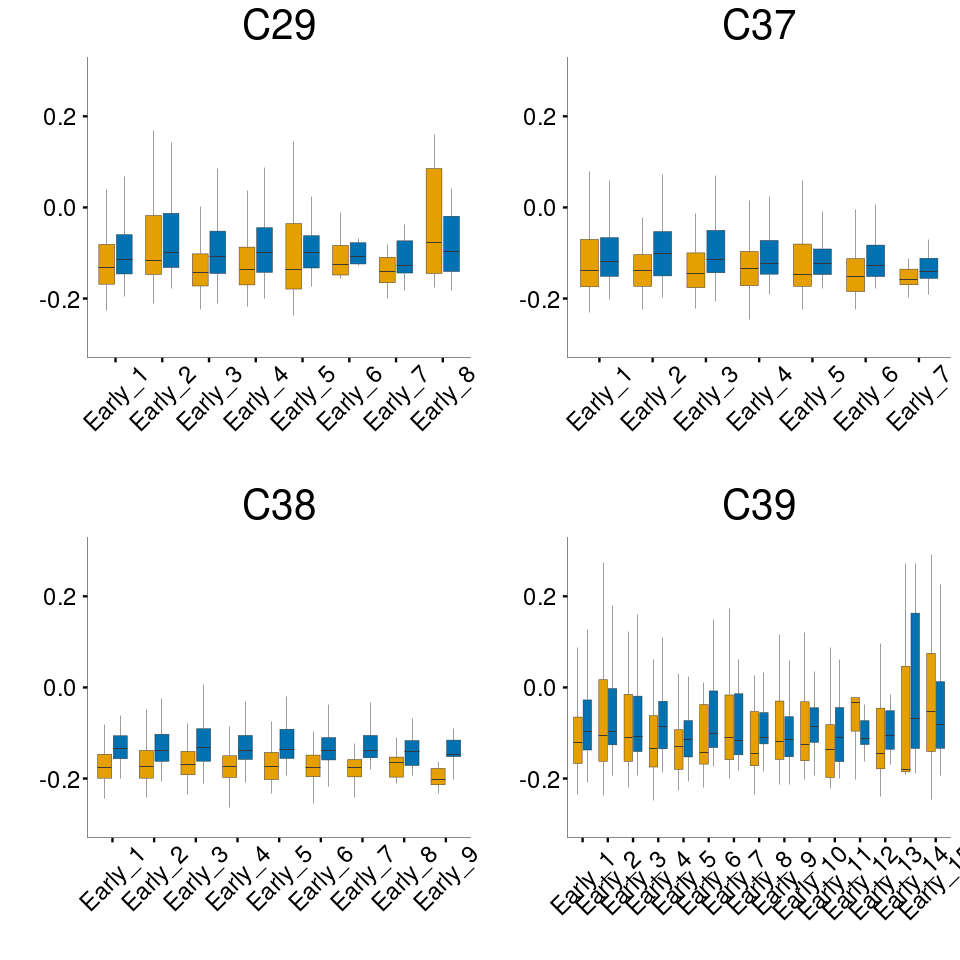

In [ ]:
c29_order <- paste0('Early_', 1:8)

c37_order <- paste0('Early_', 1:7)

c38_order <- paste0('Early_', 1:9)

c39_order <- paste0('Early_', 1:15)

early_list <- list()
early_list[[1]] <- c29_order
early_list[[2]] <- c37_order
early_list[[3]] <- c38_order
early_list[[4]] <- c39_order

rna_cell_cycle_path = paste0(projdir, '/csv/figure2/mcg_leiden_fibro_snmct_cc_rna.csv')
rna_cell_cycle = as.data.frame(fread(rna_cell_cycle_path), sep='\t')

rna_cell_cycle$mcg_leiden <- gsub('Fibro', 'Early', rna_cell_cycle$mcg_leiden)
rna_cell_cycle$mcg_leiden <- gsub('Inter', 'Transitional', rna_cell_cycle$mcg_leiden)
rna_cell_cycle$mcg_leiden <- gsub('IPS', 'Late', rna_cell_cycle$mcg_leiden)

mask <- str_split_i(rna_cell_cycle$mcg_leiden, '_', 1) == 'Early'
rna_cell_cycle <- rna_cell_cycle[mask,]

make_plot <- function(tmp_df) {
    ggplot(tmp_df, aes(x = mcg_leiden, y = value, fill = variable)) +
    geom_boxplot(outlier.shape = NA, linewidth=0.1) +
    labs(x = "", y = "", title = d, fill = "")  +
    theme_bw() +
    clone_theme +
    theme(axis.line = element_line(linewidth=0.1),
         axis.text.x = element_text(color='black', size=14, vjust=0.5, hjust=0.5, angle=45),
         axis.text.y = element_text(color='black', size=14, angle=0),
         axis.ticks = element_line()) +
    scale_fill_manual(values=cc_hexes) +
    ylim(-0.3, 0.3)
}

w = 8
h = 8
options(repr.plot.width=w, repr.plot.height=h)
plots <- list()

for (i in seq_along(donors)) {
    d <- donors[i]
    tmp_cc <- rna_cell_cycle[rna_cell_cycle$donor == d, ]
    mc_order <- early_list[[i]]
    tmp_cc$mcg_leiden <- factor(tmp_cc$mcg_leiden, levels=mc_order)
    plots[[i]] <- make_plot(tmp_cc)
}

combined_plot <- plot_grid(plotlist = plots, nrow = 2, align = "hv")
combined_plot

### C: PMD methylation of Early mC clusters

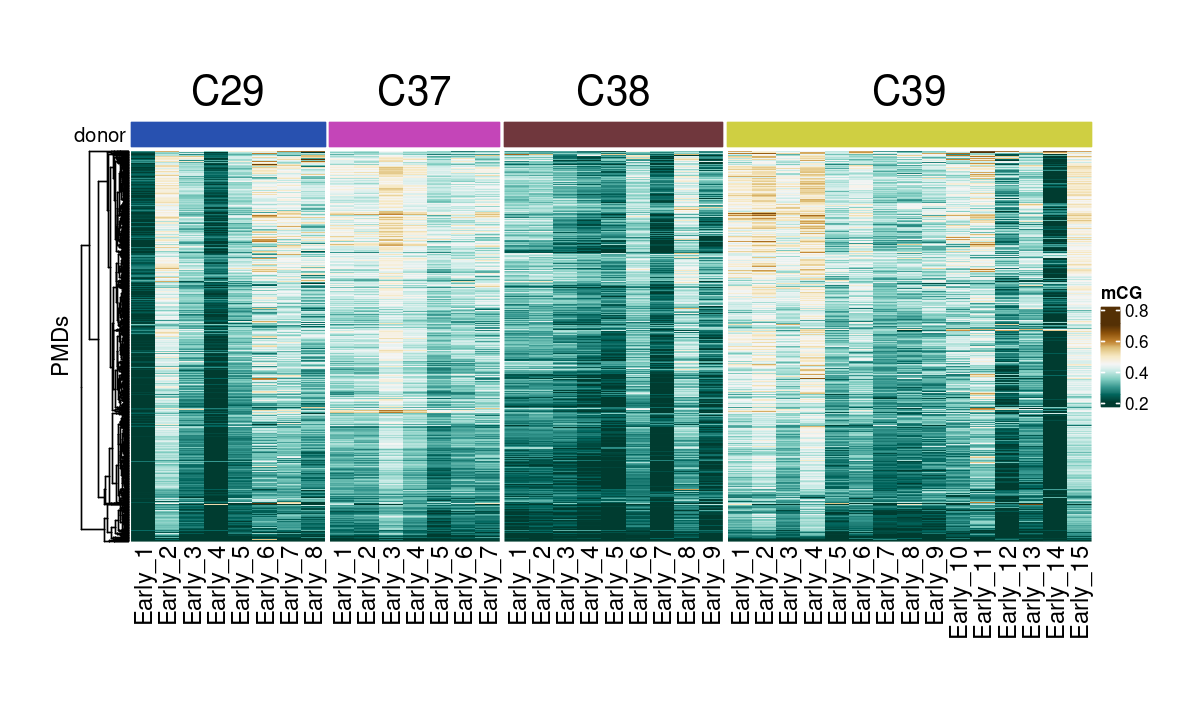

In [ ]:
pmds_heatmap_path = paste0(projdir, '/csv/figure2/mcg_leiden_fibro_pmd_mcg.csv')
pmds_heatmap = read.csv(pmds_heatmap_path, sep='\t')
pmds_heatmap = pmds_heatmap[,-1]
colnames(pmds_heatmap) <- gsub('Fibro', 'Early', colnames(pmds_heatmap))

cols <- colnames(pmds_heatmap)
sample_num <- as.integer(sub("^C(\\d+)_.*", "\\1", cols))
rep_num    <- as.integer(sub(".*_(\\d+)$", "\\1", cols))
ord <- order(sample_num, rep_num)
cols_sorted <- cols[ord]
cols_clean <- sub("^C\\d+_", "", cols_sorted)
pmds_heatmap <- pmds_heatmap[,cols_sorted]
colnames(pmds_heatmap) <- cols_clean

sample_num <- as.integer(sub("^C(\\d+)_.*", "\\1",cols_sorted))
col_split <- paste0('C', sample_num)
col_split

donors <- c('C29', 'C37', 'C38', 'C39')
names(donor_hexes) <- donors

col_fun <- colorRamp2(seq(0.2, 0.7, length.out = 11), rev(brewer.pal(11, "BrBG")))

column_ha = HeatmapAnnotation(donor = anno_simple(col_split, col = donor_hexes),
                              show_annotation_name=TRUE,
                                  annotation_name_side = 'left',
                                    gp = gpar(fontsize=20, col = "black"))

w = 10
h = 6
options(repr.plot.width=w, repr.plot.height=h)

ht <- Heatmap(
    pmds_heatmap,
    name = "mCG",
    col = col_fun,
    row_names_side = "left",
    column_names_side = "bottom",
    top_annotation = column_ha,
    show_row_names = TRUE,
    show_column_names = TRUE,
    cluster_rows = TRUE,
    cluster_columns = FALSE,
    heatmap_width = unit(22, "cm"),
    heatmap_height = unit(12, "cm"),
    row_names_gp = gpar(fontsize = 12),
    column_names_gp = gpar(fontsize = 14),
    column_title_gp = gpar(fontsize = 24),
    column_names_rot = 90,
    column_split = col_split,
    column_title = '',
    row_title = 'PMDs',
    use_raster = TRUE,
    raster_quality = 5
)
p <- as.ggplot(ht)
p

### E: Inter2 proportion in Early mC clusters

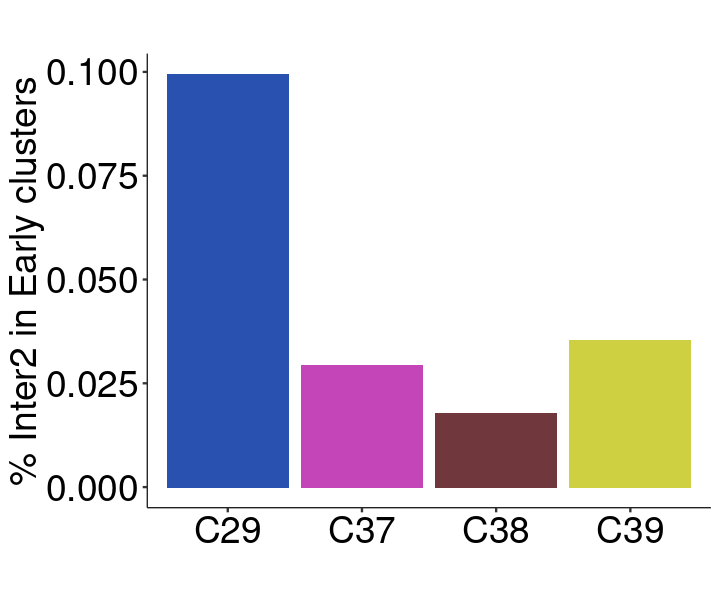

In [ ]:
mcg_inter2_path <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures/csv/figure2/snmct_donor_fibro_fisher.csv'
mcg_inter2 <- as.data.frame(fread(mcg_inter2_path))
mcg_inter2$cluster <- gsub('Fibro', 'Early', mcg_inter2$cluster)

w = 6
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(mcg_inter2, aes(x = donor, y = value, fill = donor)) +
  geom_bar(stat = "identity", position='dodge') +
  labs(x = "", y = "% Inter2 in Early clusters", title = "", fill = "") +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x = element_text(size = 22, angle = 0, hjust = 0.5, color='black'),
    axis.text.y = element_text(size = 22, color='black'),
    axis.title = element_text(size = 22),
    plot.title = element_text(size = 22, hjust = 0.5),
     axis.line.x = element_line(linewidth=0.25),
     axis.line.y = element_line(linewidth=0.25),
        axis.ticks.x = element_line(linewidth=0.5),
        axis.ticks.y = element_line(linewidth=0.5),
  ) +
  scale_fill_manual(values=donor_hexes)

### F: RNA cluster composition of mC clusters

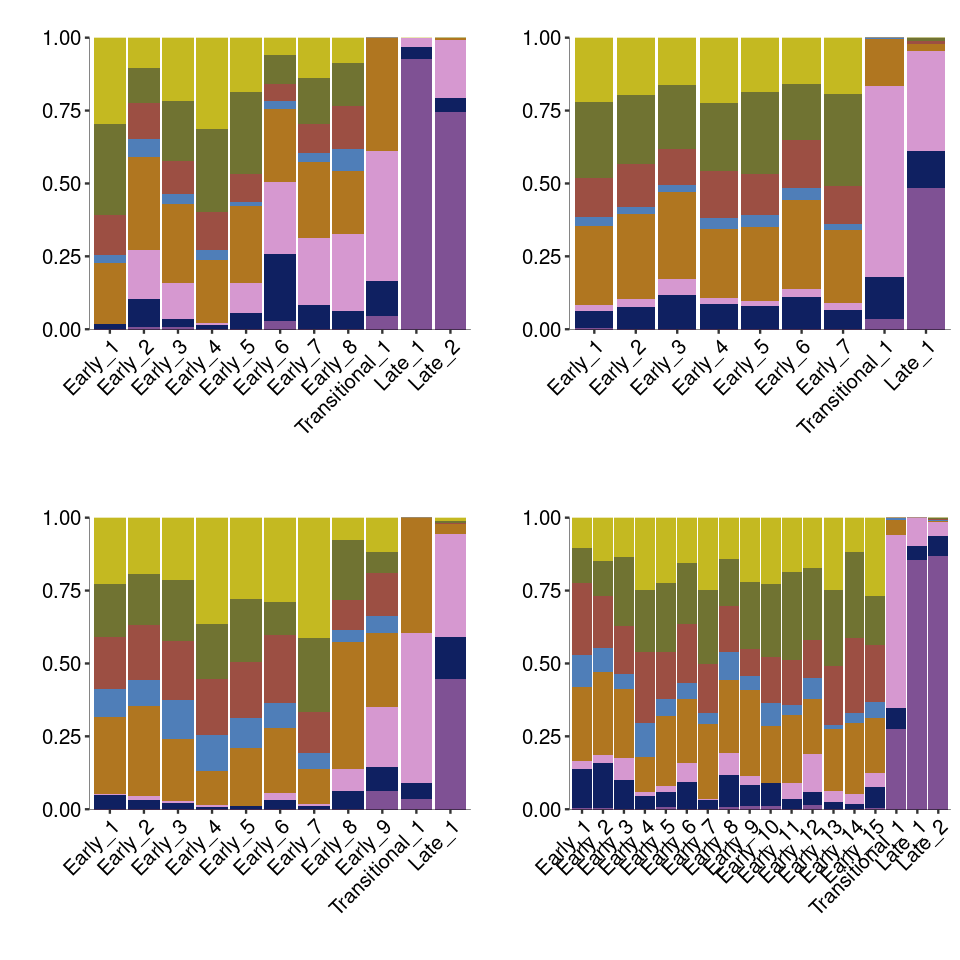

In [ ]:
rna_order <- c('Start', 'Sendai', 'Delayed',
               'Fail1', 'Inter1', 'Inter2', 'Fail2', 'IPS')
rna_hexes <- c('#C4B921', '#707332', '#9C4F43',
                 '#4F7EB8', '#B07620', '#D698D0', '#0F2061', '#7F5194')

mc_rna_dist_path <- paste0(projdir, '/csv/figure2/snmct_rna_mc_cluster_props.csv')
mc_rna_dist <- as.data.frame(fread(mc_rna_dist_path))

make_plot <- function(tmp_df) {

    ggplot(tmp_df, aes(x = cluster, y = prop, fill = state)) +
      geom_bar(stat = "identity") +
      labs(x = "",y = "",title = '',fill = "RNA cluster") +
      scale_y_continuous(limits = c(0, 1), expand = c(0, 0)) +
      theme_bw() +
      theme(
        axis.text.x = element_text(size = 12, angle = 45, hjust = 1, color='black'),
        axis.text.y = element_text(size = 12, color='black'),
        plot.title = element_text(size = 12, hjust = 0.5, color='black'),
        axis.title = element_text(size = 18),
         axis.line.x = element_line(linewidth=0.1),
         axis.line.y = element_line(linewidth=0.1),
         panel.border = element_blank(),
         panel.grid = element_blank(),
         panel.background = element_blank(),
         plot.background  = element_blank(),
        legend.position = "none"
      ) +
      scale_fill_manual(values=rna_hexes)
}

mc_rna_dist$V1 <- gsub('Fibro', 'Early', mc_rna_dist$V1)
mc_rna_dist$V1 <- gsub('Inter', 'Transitional', mc_rna_dist$V1)
mc_rna_dist$V1 <- gsub('IPS', 'Late', mc_rna_dist$V1)

plots <- list()

for (i in seq_along(donors)) {
    d <- donors[i]
    mask <- mc_rna_dist$donor == d
    tmp_dist <- mc_rna_dist[mask,]
    tmp_dist <- tmp_dist[,-ncol(tmp_dist)]
    rownames(tmp_dist) <- tmp_dist$V1
    tmp_dist <- tmp_dist[,-1]
    tmp_dist$cluster <- rownames(tmp_dist)
    df_long <- tmp_dist %>% pivot_longer(-cluster, names_to = "state", values_to = "prop")
    df_long$state <- factor(df_long$state, levels=rna_order)
    df_long <- df_long %>% mutate(cluster = recode(cluster, !!!ips_dict))

    mc_order <- clust_list[[i]]
    df_long$cluster <- factor(df_long$cluster, levels=mc_order)
    plots[[i]] = make_plot(df_long)
}

w = 8
h = 8
options(repr.plot.width=w, repr.plot.height=h)

p <- plot_grid(plotlist = plots, nrow=2)
p

### G: log2FC of Inter2/Fail1/Fail2 per mC cluster

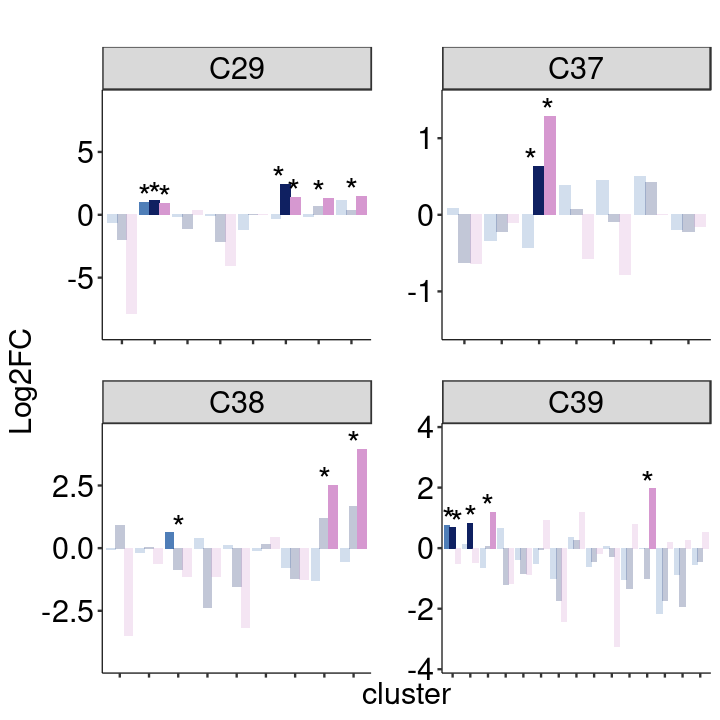

In [ ]:
fisher_rna_path <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures/csv/figure2/snmct_donor_fibro_fisher_fail_inter.csv'
fisher_rna <- as.data.frame(fread(fisher_rna_path))
fisher_rna$cluster <- gsub('Fibro', 'Early', fisher_rna$cluster)

fisher_order <- c('Fail1', 'Fail2', 'Inter2')

fisher_rna$rna_cluster <- factor(fisher_rna$rna_cluster, levels=fisher_order)
mask <- !is.na(fisher_rna$rna_cluster)
fisher_rna <- fisher_rna[mask,]

fibro_order <- unique(fisher_rna$mc_cluster)

donor_prefix <- sub("_Fibro_[0-9]+$", "", fibro_order)
fibro_num <- as.numeric(sub(".*_Fibro_", "", fibro_order))

fibro_order <- fibro_order[order(donor_prefix, fibro_num)]
fisher_rna$mc_cluster <- factor(fisher_rna$mc_cluster, levels=fibro_order)

fisher_rna <- fisher_rna %>%
  arrange(match(mc_cluster, fibro_order)) %>%
  mutate(cluster_uniq = paste(cluster, donor, sep = "___")) %>%
  mutate(cluster_uniq = factor(cluster_uniq, levels = unique(cluster_uniq)))

fisher_rna$cluster_uniq <- factor(fisher_rna$cluster_uniq, levels = unique(fisher_rna$cluster_uniq))

fisher_rna <- fisher_rna %>%
  mutate(sig = ifelse(neglog10p > 2, "Significant", "NS"))

summary_stats <- fisher_rna %>%
  group_by(donor, cluster_uniq, rna_cluster) %>%
  summarise(
    mean_val = mean(log2fc, na.rm = TRUE),
    se_val = sd(log2fc, na.rm = TRUE) / sqrt(n()),
    sig = first(sig),
    .groups = "drop"
  ) %>%
  mutate(
    bar_top = mean_val + ifelse(is.na(se_val), 0, se_val),
    bar_bottom = mean_val - ifelse(is.na(se_val), 0, se_val)
  )

donor_ranges <- summary_stats %>%
  group_by(donor) %>%
  summarise(
    y_extreme = max(abs(c(bar_top, bar_bottom)), na.rm = TRUE) * 1.15
  ) %>%
  mutate(y_max = y_extreme, y_min = -y_extreme) %>%
  select(donor, y_min, y_max)

blank_data <- donor_ranges %>%
  tidyr::pivot_longer(cols = c(y_min, y_max), values_to = "log2fc") %>%
  select(donor, log2fc)

star_data <- summary_stats %>%
  filter(sig == "Significant") %>%
  left_join(donor_ranges, by = "donor") %>%
  mutate(
    star_y = ifelse(mean_val >= 0, bar_top + 0.05 * y_max, bar_bottom - 0.05 * y_max)
  )

p2 <- ggplot(fisher_rna, aes(x = cluster_uniq, y = log2fc, fill = rna_cluster, alpha = sig)) +
  stat_summary(fun = mean, geom = "bar", position = position_dodge(width = 0.9)) +
  stat_summary(fun.data = mean_se, geom = "errorbar",
               position = position_dodge(width = 0.9), width = 0.2) +
  geom_blank(data = blank_data, aes(x = 1, y = log2fc), inherit.aes = FALSE) +
  geom_text(
    data = star_data,
    aes(x = cluster_uniq, y = star_y, group = rna_cluster),
    label = "*", size = 7, color = "black",
    position = position_dodge(width = 0.9),
    inherit.aes = FALSE
  ) +
  scale_x_discrete(labels = function(x) sub("___.*$", "", x)) +
  facet_wrap(~ donor, nrow = 2, ncol = 2, scales = "free") +
  labs(x = "cluster", y = "Log2FC", title = "") +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x = element_blank(),
    axis.text.y = element_text(size = 18, color='black'),
    axis.title = element_text(size = 18),
    plot.title = element_text(size = 18, hjust = 0.5),
    axis.line.x = element_line(linewidth=0.25),
    axis.line.y = element_line(linewidth=0.25),
    axis.ticks.x = element_line(linewidth=0.5),
    axis.ticks.y = element_line(linewidth=0.5),
    strip.text = element_text(color='black', size=18),
    panel.spacing = unit(1.5, "lines")
  ) +
  scale_fill_manual(values = clust_hexes) +
  scale_alpha_manual(values = c("Significant" = 1, "NS" = 0.25), guide = "none")

w = 6
h = 6
options(repr.plot.width=w, repr.plot.height=h)
p2

### H: correlation of log2FC between RNA clusters

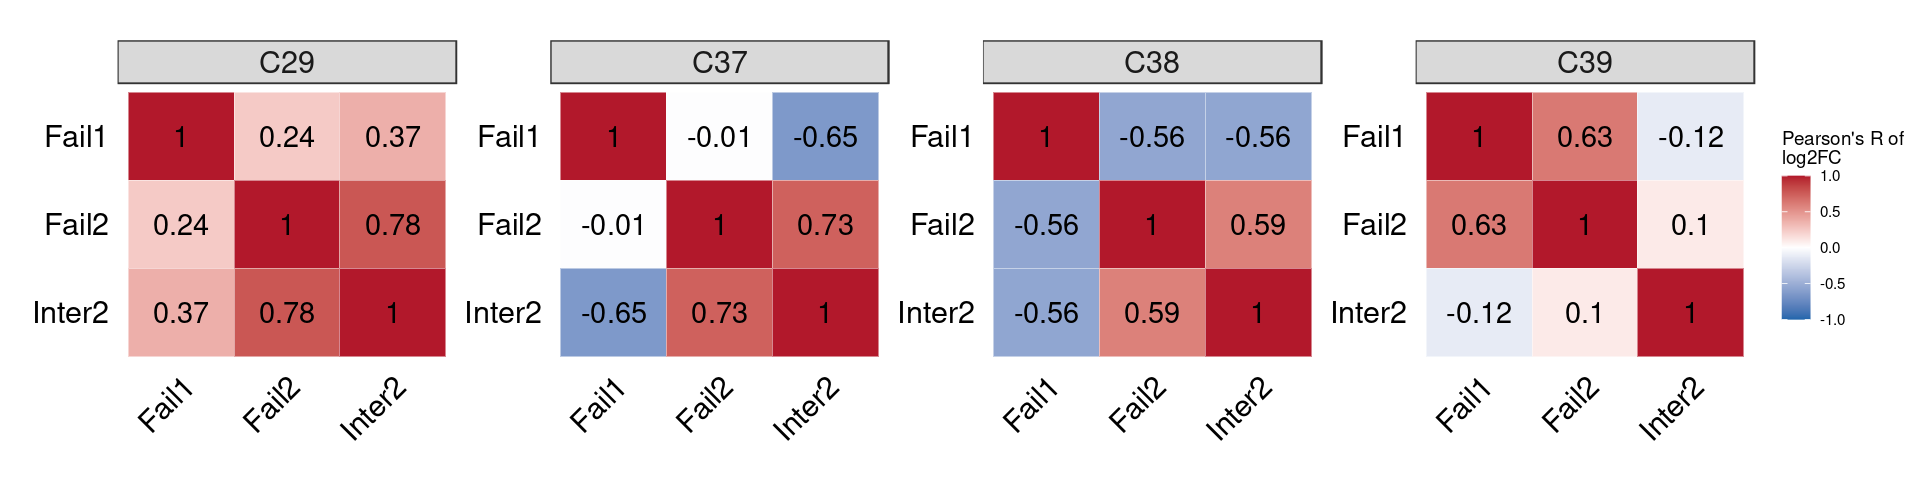

In [ ]:
fisher_rna_path <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures/csv/figure2/snmct_donor_fibro_fisher_fail_inter.csv'
fisher_rna <- as.data.frame(fread(fisher_rna_path))
fisher_rna$cluster <- gsub('Fibro', 'Early', fisher_rna$cluster)

fisher_rna <- fisher_rna %>% filter(rna_cluster != "Inter1")

compute_donor_cor <- function(df) {
  wide <- df %>%
    select(cluster, rna_cluster, log2fc) %>%
    pivot_wider(names_from = rna_cluster, values_from = log2fc)

  mat <- as.matrix(wide %>% select(-cluster))
  cor(mat, use = "pairwise.complete.obs")
}

donors <- unique(fisher_rna$donor)

cor_list <- lapply(donors, function(d) {
  sub <- fisher_rna %>% filter(donor == d)
  cmat <- compute_donor_cor(sub)

  cor_df <- as.data.frame(as.table(cmat))
  colnames(cor_df) <- c("cluster_x", "cluster_y", "r")
  cor_df$donor <- d
  cor_df$n_clusters <- n_distinct(sub$cluster)
  cor_df
})

cor_all <- bind_rows(cor_list)

rna_order <- c("Fail1", "Fail2", "Inter2")
cor_all$cluster_x <- factor(cor_all$cluster_x, levels = rna_order)
cor_all$cluster_y <- factor(cor_all$cluster_y, levels = rna_order)

cor_all <- cor_all %>%
  mutate(donor_label = paste0("donor ", donor, "  (n=", n_clusters, " clusters)"))

p <- ggplot(cor_all, aes(x = cluster_x, y = cluster_y, fill = r)) +
  geom_tile(color = "white") +
  geom_text(aes(label = round(r, 2)), size = 6) +
  facet_wrap(~ donor, scales = "free", nrow=1) +
  scale_fill_gradient2(low = "#2166AC", mid = "white", high = "#B2182B",
                        midpoint = 0, limits = c(-1, 1), name = "Pearson's R of\nlog2FC") +
  labs(x = "", y = "", title = "") +
  scale_y_discrete(limits = rev(rna_order)) +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x = element_text(size = 18, angle = 45, hjust = 1, color = 'black'),
    axis.text.y = element_text(size = 18, color = 'black'),
    strip.text = element_text(size = 18),
    panel.grid = element_blank(),
  legend.position = 'right'
  )

w = 16
h = 4
options(repr.plot.width=w, repr.plot.height=h)
p

In [ ]:
sessionInfo()

In [ ]:
Sys.time()